In [1]:
import sys
src_path = "/home/souvik/codes/foresee-main"
sys.path.append(src_path)

import numpy as np
import os
from matplotlib import pyplot as plt
import math
import random
from skhep.math.vectors import LorentzVector, Vector3D
from scipy import interpolate
from matplotlib import gridspec
import os, inspect

In [2]:
from src_modified.foresee import Foresee, Utility, Model
foresee = Foresee()

energy = "14"
modelname="U1_slzplln"
model = Model(modelname, path="./")

In [3]:
sys.path.insert(1, os.path.join(os.path.dirname(os.path.realpath(
                inspect.getfile(inspect.currentframe()))), "/home/souvik/codes/darkcast_chiral/"))
import darkcast 

In [4]:
model.add_production_2bodydecay(
    pid0 = "111",
    pid1 = "22",
    br = "2*0.99 * (coupling/0.303)**2 * pow(1.-pow(mass/self.masses('111'),2),3)",
#     br = "2*0.99 * (coupling)**2 * pow(1.-pow(mass/self.masses('111'),2),3)",
    generator = "EPOSLHC",
    energy = energy,
    nsample = 50
)

model.add_production_2bodydecay(
    pid0 = "221",
    pid1 = "22",
    br = "2*0.25*0.39  * (coupling/0.303)**2 * pow(1.-pow(mass/self.masses('221'),2),3)",
#     br = "2*0.39 * (coupling)**2 * pow(1.-pow(mass/self.masses('221'),2),3)",
    generator = "EPOSLHC",
    energy = energy,
    nsample = 50, 
)

In [5]:
masses_brem = [ 
   0.01  ,  0.0126,  0.0158,  0.02  ,  0.0251,  0.0316,  0.0398,
   0.0501,  0.0631,  0.0794,  0.1   ,  0.1122,  0.1259,  0.1413,
   0.1585,  0.1778,  0.1995,  0.2239,  0.2512,  0.2818,  0.3162,
   0.3548,  0.3981,  0.4467,  0.5012,  0.5623,  0.6026,  0.631 ,
   0.6457,  0.6607,  0.6761,  0.6918,  0.7079,  0.7244,  0.7413,
   0.7586,  0.7762,  0.7943,  0.8128,  0.8318,  0.8511,  0.871 ,
   0.8913,  0.912 ,  0.9333,  0.955 ,  0.9772,  1.    ,  1.122 ,
   1.2589,  1.4125,  1.5849,  1.7783,  1.9953,  2.2387,  2.5119,
   2.8184,  3.1623,  3.9811,  5.0119,  6.3096,  7.9433, 10.    
]

model.add_production_direct(
    label = "Brem",
    energy = energy,
    condition = None, #"1./0.3**2 * (p.pt<1)",
#     condition = "p.pt<1",
    coupling_ref=1,
    masses = masses_brem,
)

In [6]:
masses1 = np.logspace(-3, np.log10(4), 60)
masses2 = np.logspace(np.log10(4),np.log10(6), 40)
masses3 = np.logspace(np.log10(6), 1, 10)
masses = np.array(sorted(list(set(np.concatenate((masses1,masses2,masses3))))))
foresee.set_model(model=model)
# for mass in masses:
#     foresee.get_llp_spectrum(mass=mass, coupling=1, luminosity=3000, mincount=0,
#                                           do_plot=False, stat_cuts=None, save_file=True)

In [7]:
%%time
distance, selection, length, luminosity = 620, "np.sqrt(x.x**2 + x.y**2)< 1", 10, 3000
energy, setup, name = '14', "default", "U1_X"

foresee.set_detector(distance=distance, selection=selection, length=length, luminosity=luminosity, name=name)

foresee.slp_event_gen(masses, energy, N=1, modes=None, nsample=1, U=1e-3, sample=1, mN = 1/3,
                      preselectioncuts="th<1/630", coup_ref=1, extend_to_low_pt_scales={})

CPU times: user 1min 2s, sys: 25.1 ms, total: 1min 2s
Wall time: 1min 2s


In [8]:
%%time
#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings = foresee.get_events_slp(nsample=1, mass=mass, xH=-2, model1="U1_X_2n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_e/"+energy+"TeV_"+setup+"2n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings = foresee.get_events_slp(nsample=1, mass=mass, xH = -1.2, model1="U1_X_12n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_e/"+energy+"TeV_"+setup+"12n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings  = foresee.get_events_slp(nsample=1, mass=mass, xH = 0, model1="U1_X_0", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
    
#save results
np.save("model/results_RHN3_e/"+energy+"TeV_"+setup+"0.npy",[masses,couplings,list_nevents])

#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings  = foresee.get_events_slp(nsample=1, mass=mass, xH=2, model1="U1_X_2p", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_e/"+energy+"TeV_"+setup+"2p.npy",[masses,couplings,list_nevents])

/home/souvik/anaconda3/lib/python3.11/site-packages/numpy/lib/npyio.py:521: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


CPU times: user 2min 39s, sys: 4.6 s, total: 2min 44s
Wall time: 2min 44s


/tmp/ipykernel_35103/3495753237.py:14: UserWarning: The following kwargs were not used by contour: 'clabel'
  ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


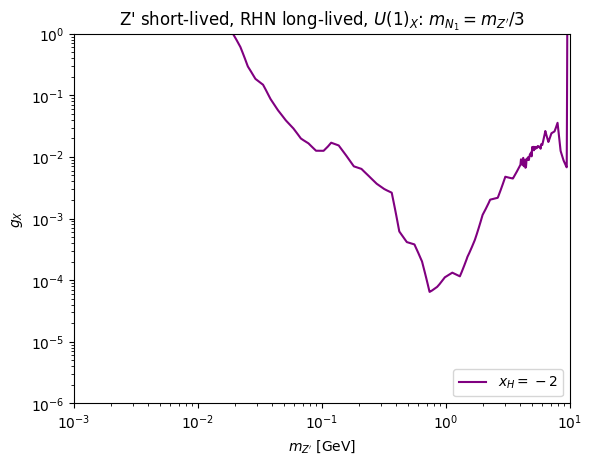

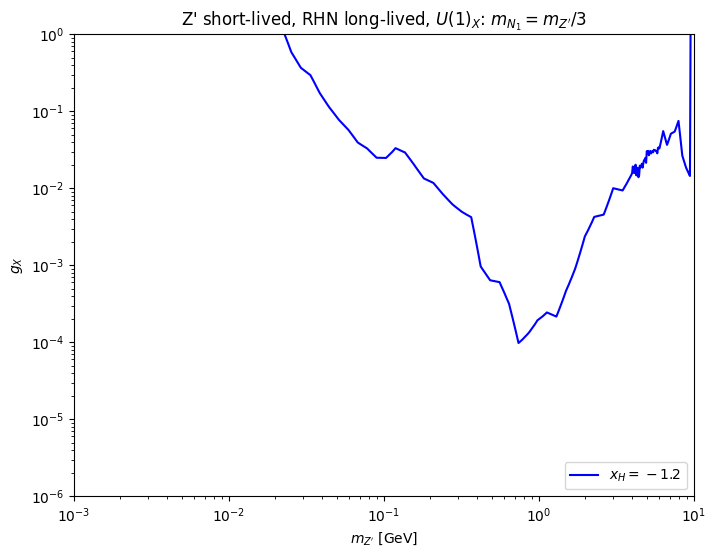

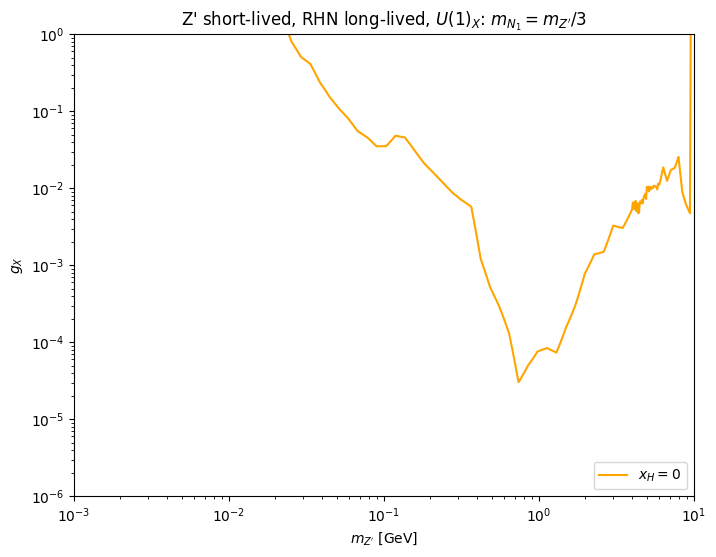

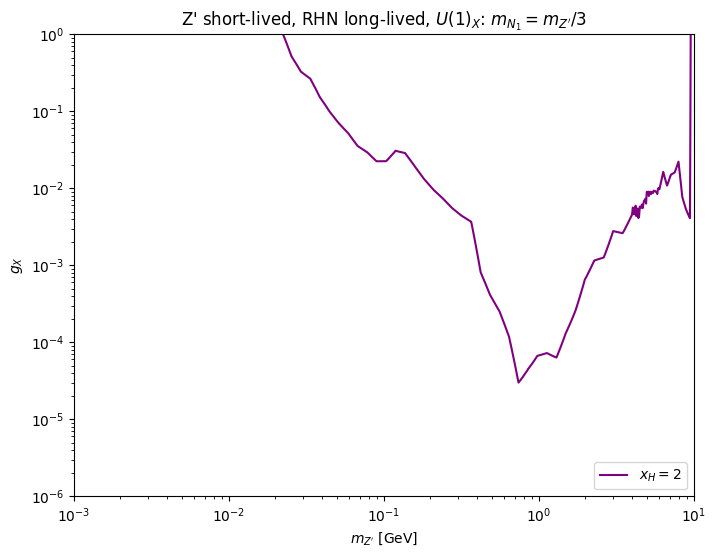

In [9]:
setups = [
         ["14TeV_default2n.npy",    r"$x_H = -2$"  , "purple", "solid", 0., 3],#*150/3000],
         ["14TeV_default12n.npy",    r"$x_H = -1.2$"  , "blue", "solid", 0., 3],#*150/3000],
         ["14TeV_default0.npy",    r"$x_H = 0$"  , "orange", "solid", 0., 3],#*150/3000],  
         ["14TeV_default2p.npy",    r"$x_H = 2$"  , "purple", "solid", 0., 3]#*150/3000]]
]

for setup in setups:
    fig, ax = plt.subplots()
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load(model.modelpath+"model/results_RHN3_e/"+filename, allow_pickle=True, encoding='latin1')
    m, c = np.meshgrid(masses, couplings)
    n = np.log10(np.array(nsignals).T+1e-20)
    ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    ax.plot([0],[0],label=label, color=color)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$m_{Z'}$ [GeV]") 
    ax.set_ylabel(r"$g_X$")
    plt.rcParams["figure.figsize"]=(8,6)
    ax.set_xlim(1e-3, 10)
    # ax.set_ylim(1e-6, 1)
    ax.legend(loc = "lower right")
    ax.set_title(r"Z' short-lived, RHN long-lived, $U(1)_X$: $m_{N_1} = m_{Z'}/3$")
    plt.savefig(model.modelpath+"model/results_RHN3_e/plots/"+filename+".png")

In [10]:
%%time
distance, selection, length, luminosity = 620, "np.sqrt(x.x**2 + x.y**2)< 1", 10, 3000
energy, setup, name = '14', "default", "U1_X"

foresee.set_detector(distance=distance, selection=selection, length=length, luminosity=luminosity, name=name)

foresee.slp_event_gen(masses, energy, N=2, modes=None, nsample=1, U=1e-3, sample=1, mN = 1/3,
                      preselectioncuts="th<1/630", coup_ref=1, extend_to_low_pt_scales={})

CPU times: user 1min 4s, sys: 11.9 ms, total: 1min 4s
Wall time: 1min 4s


In [11]:
%%time
#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings = foresee.get_events_slp(nsample=1, mass=mass, xH=-2, model1="U1_X_2n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_mu/"+energy+"TeV_"+setup+"2n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings = foresee.get_events_slp(nsample=1, mass=mass, xH = -1.2, model1="U1_X_12n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_mu/"+energy+"TeV_"+setup+"12n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings  = foresee.get_events_slp(nsample=1, mass=mass, xH = 0, model1="U1_X_0", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
    
#save results
np.save("model/results_RHN3_mu/"+energy+"TeV_"+setup+"0.npy",[masses,couplings,list_nevents])

#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings  = foresee.get_events_slp(nsample=1, mass=mass, xH=2, model1="U1_X_2p", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_mu/"+energy+"TeV_"+setup+"2p.npy",[masses,couplings,list_nevents])

CPU times: user 8min 53s, sys: 7.32 s, total: 9min
Wall time: 9min 1s


/tmp/ipykernel_35103/208629427.py:14: UserWarning: The following kwargs were not used by contour: 'clabel'
  ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


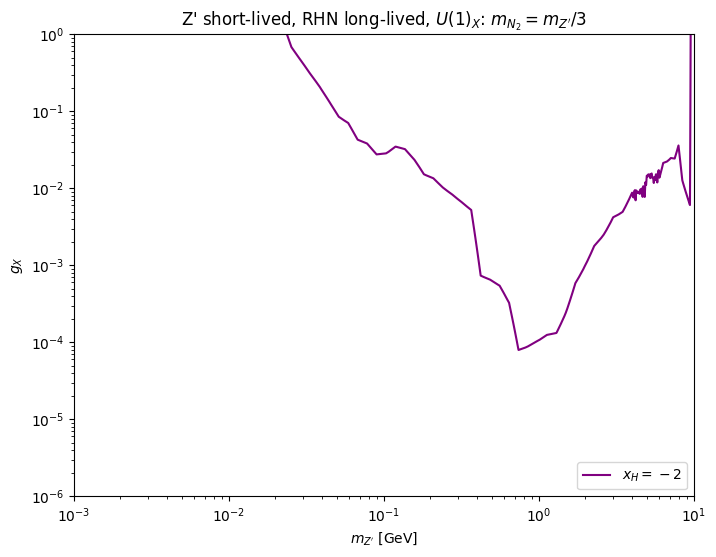

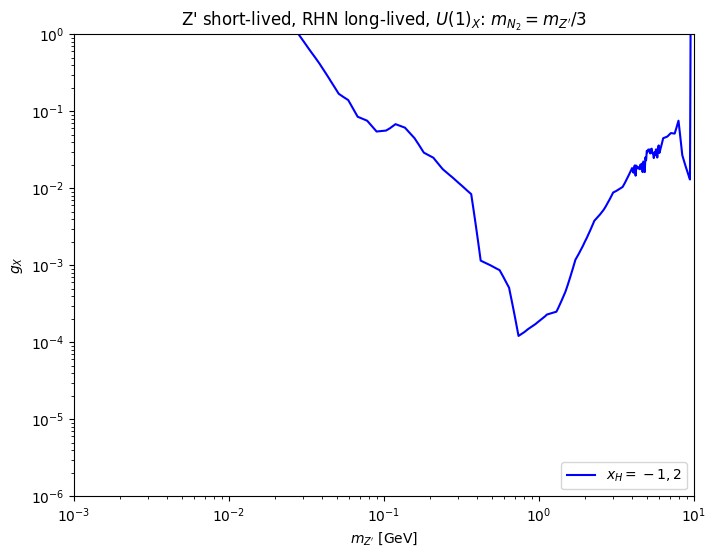

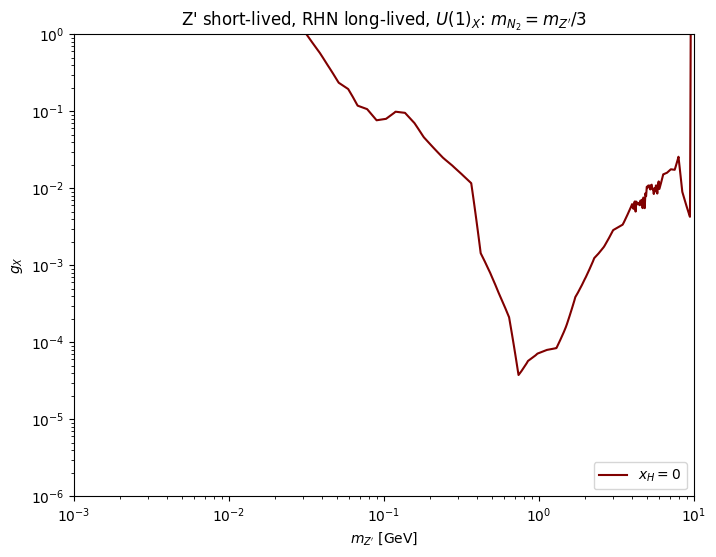

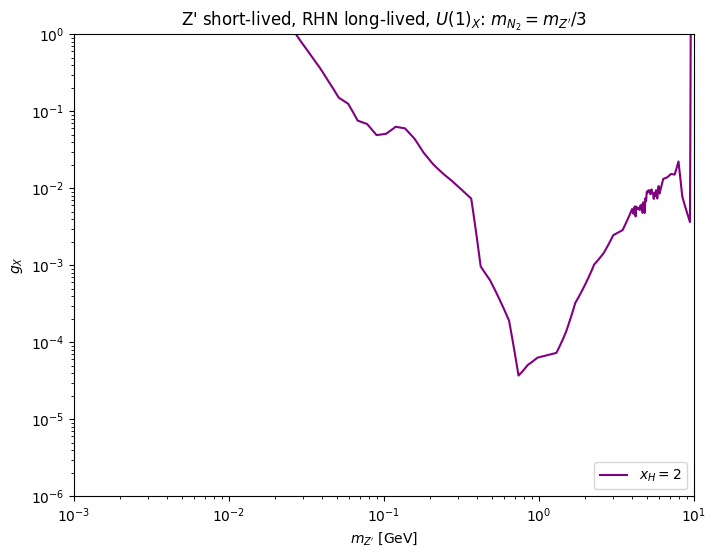

In [12]:
setups = [
         ["14TeV_default2n.npy",    r"$x_H = -2$"  , "purple", "solid", 0., 3],#*150/3000],
         ["14TeV_default12n.npy",    r"$x_H = -1,2$"  , "blue", "solid", 0., 3],#*150/3000],
         ["14TeV_default0.npy",    r"$x_H = 0$"  , "maroon", "solid", 0., 3],#*150/3000]]  
         ["14TeV_default2p.npy",    r"$x_H = 2$"  , "purple", "solid", 0., 3]#*150/3000]]
]

for setup in setups:
    fig, ax = plt.subplots()
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load(model.modelpath+"model/results_RHN3_mu/"+filename, allow_pickle=True, encoding='latin1')
    m, c = np.meshgrid(masses, couplings)
    n = np.log10(np.array(nsignals).T+1e-20)
    ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    ax.plot([0],[0],label=label, color=color)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$m_{Z'}$ [GeV]") 
    ax.set_ylabel(r"$g_X$")
    plt.rcParams["figure.figsize"]=(8,6)
    ax.set_xlim(1e-3, 10)
    ax.set_ylim(1e-6, 1)
    ax.legend(loc = "lower right")
    ax.set_title(r"Z' short-lived, RHN long-lived, $U(1)_X$: $m_{N_2} = m_{Z'}/3$")
    plt.savefig(model.modelpath+"model/results_RHN3_mu/plots/"+filename+".png")

In [13]:
%%time
distance, selection, length, luminosity = 620, "np.sqrt(x.x**2 + x.y**2)< 1", 10, 3000
energy, setup, name = '14', "alternative", "U1_X_phi4"

foresee.set_detector(distance=distance, selection=selection, length=length, luminosity=luminosity, name=name)

foresee.slp_event_gen(masses, energy, N=1, modes=None, nsample=1, U=1e-3, sample=1, mN = 1/3,
                      preselectioncuts="th<1/630", coup_ref=1, extend_to_low_pt_scales={})

CPU times: user 1min 7s, sys: 24.2 ms, total: 1min 7s
Wall time: 1min 7s


In [14]:
%%time
#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings = foresee.get_events_slp(nsample=1, mass=mass, xH=-2, model1="U1_X_phi4_2n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_e/"+energy+"TeV_"+setup+"2n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings = foresee.get_events_slp(nsample=1, mass=mass, xH = -1.2, model1="U1_X_phi4_12n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_e/"+energy+"TeV_"+setup+"12n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings  = foresee.get_events_slp(nsample=1, mass=mass, xH = 0, model1="U1_X_phi4_0", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
    
#save results
np.save("model/results_RHN3_e/"+energy+"TeV_"+setup+"0.npy",[masses,couplings,list_nevents])

#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings  = foresee.get_events_slp(nsample=1, mass=mass, xH=2, model1="U1_X_phi4_2p", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_e/"+energy+"TeV_"+setup+"2p.npy",[masses,couplings,list_nevents])

CPU times: user 10min 48s, sys: 5.81 s, total: 10min 54s
Wall time: 10min 55s


/tmp/ipykernel_35103/341953863.py:14: UserWarning: The following kwargs were not used by contour: 'clabel'
  ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


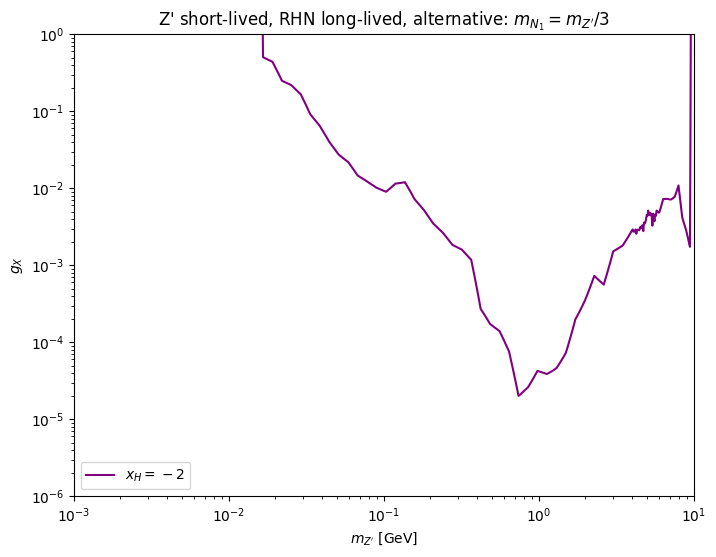

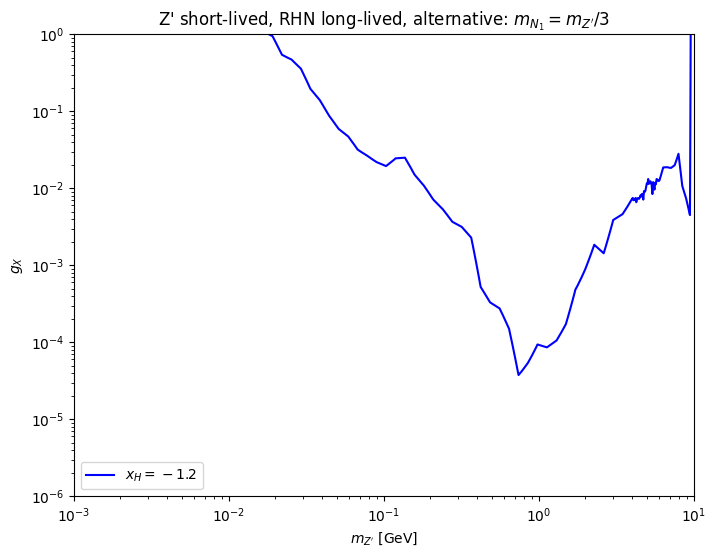

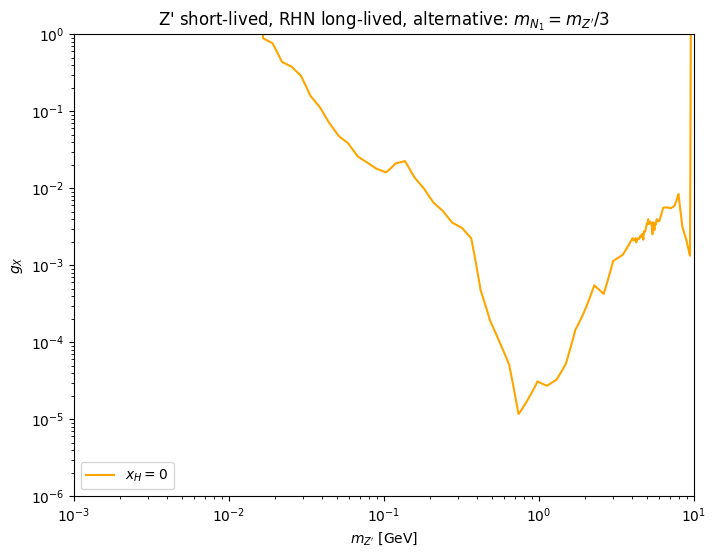

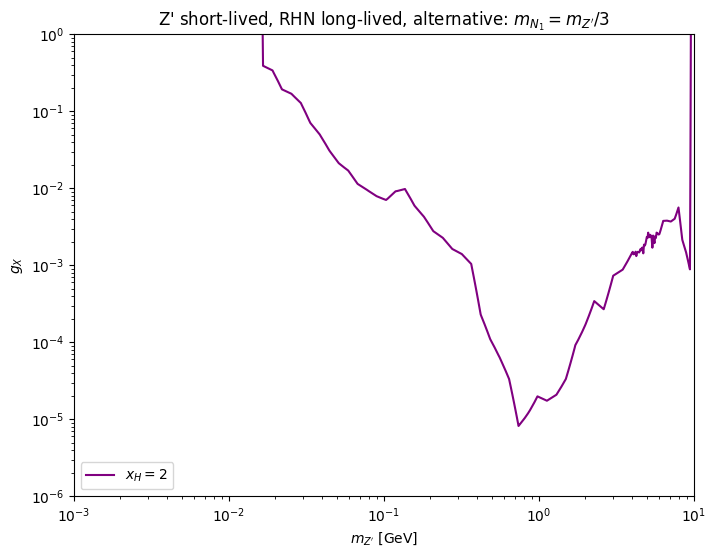

In [15]:
setups = [
         ["14TeV_alternative2n.npy",    r"$x_H = -2$"  , "purple", "solid", 0., 3],#*150/3000],
         ["14TeV_alternative12n.npy",    r"$x_H = -1.2$"  , "blue", "solid", 0., 3],#*150/3000],
         ["14TeV_alternative0.npy",    r"$x_H = 0$"  , "orange", "solid", 0., 3],#*150/3000], 
         ["14TeV_alternative2p.npy",    r"$x_H = 2$"  , "purple", "solid", 0., 3]#*150/3000]]
]

for setup in setups:
    fig, ax = plt.subplots()
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load(model.modelpath+"model/results_RHN3_e/"+filename, allow_pickle=True, encoding='latin1')
    m, c = np.meshgrid(masses, couplings)
    n = np.log10(np.array(nsignals).T+1e-20)
    ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    ax.plot([0],[0],label=label, color=color)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$m_{Z'}$ [GeV]") 
    ax.set_ylabel(r"$g_X$")
    plt.rcParams["figure.figsize"]=(8,6)
    ax.set_xlim(1e-3, 10)
    ax.set_ylim(1e-6, 1)
    ax.legend(loc = "lower left")
    ax.set_title(r"Z' short-lived, RHN long-lived, alternative: $m_{N_1} = m_{Z'}/3$")
    plt.savefig(model.modelpath+"model/results_RHN3_e/plots/"+filename+".png")

In [16]:
%%time
distance, selection, length, luminosity = 620, "np.sqrt(x.x**2 + x.y**2)< 1", 10, 3000
energy, setup, name = '14', "alternative", "U1_X_phi4"

foresee.set_detector(distance=distance, selection=selection, length=length, luminosity=luminosity, name=name)

foresee.slp_event_gen(masses, energy, N=2, modes=None, nsample=1, U=1e-3, sample=1, mN = 1/3,
                      preselectioncuts="th<1/630", coup_ref=1, extend_to_low_pt_scales={})

CPU times: user 1min 4s, sys: 20 ms, total: 1min 4s
Wall time: 1min 4s


In [17]:
%%time
#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings = foresee.get_events_slp(nsample=1, mass=mass, xH=-2, model1="U1_X_phi4_2n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_mu/"+energy+"TeV_"+setup+"2n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings = foresee.get_events_slp(nsample=1, mass=mass, xH = -1.2, model1="U1_X_phi4_12n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_mu/"+energy+"TeV_"+setup+"12n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings  = foresee.get_events_slp(nsample=1, mass=mass, xH = 0, model1="U1_X_phi4_0", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
    
#save results
np.save("model/results_RHN3_mu/"+energy+"TeV_"+setup+"0.npy",[masses,couplings,list_nevents])

#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    nevents, couplings  = foresee.get_events_slp(nsample=1, mass=mass, xH=2, model1="U1_X_phi4_2p", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-6,0,60), mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3_mu/"+energy+"TeV_"+setup+"2p.npy",[masses,couplings,list_nevents])

CPU times: user 10min 38s, sys: 5.25 s, total: 10min 43s
Wall time: 10min 43s


/tmp/ipykernel_35103/321147975.py:14: UserWarning: The following kwargs were not used by contour: 'clabel'
  ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)


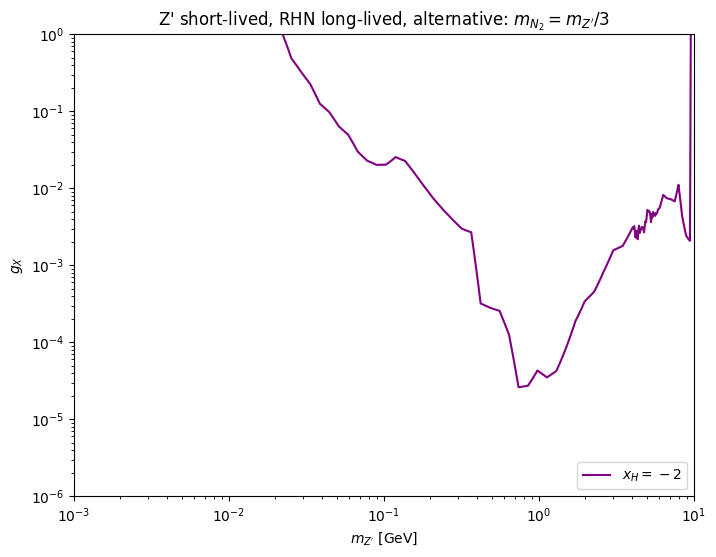

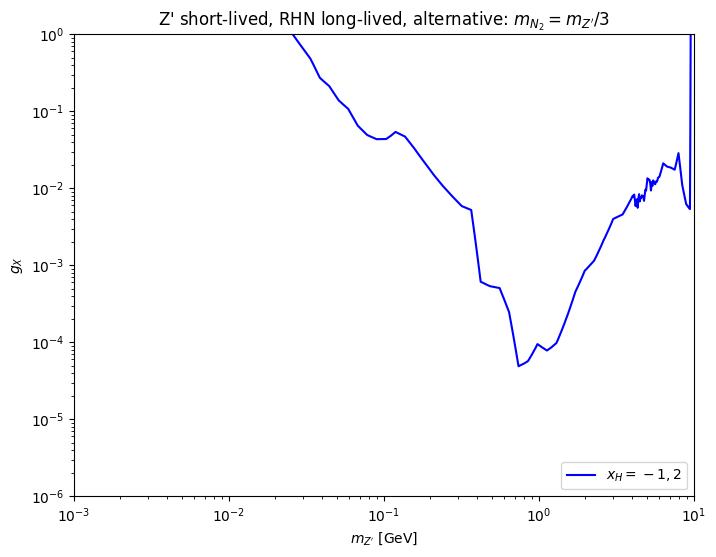

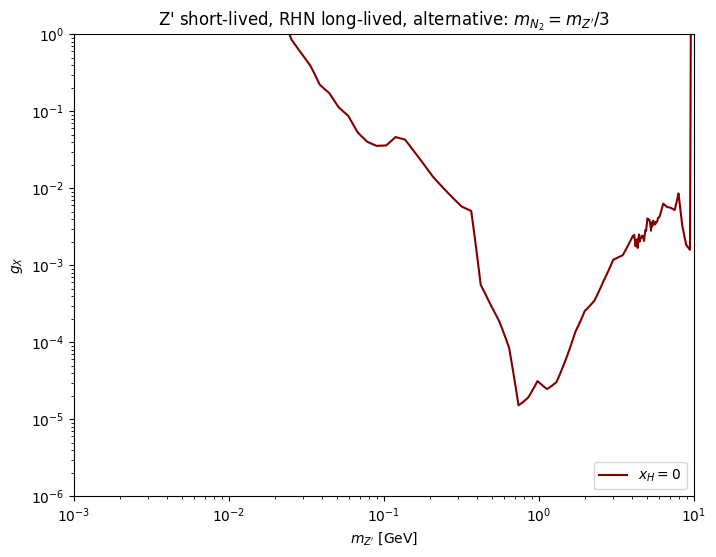

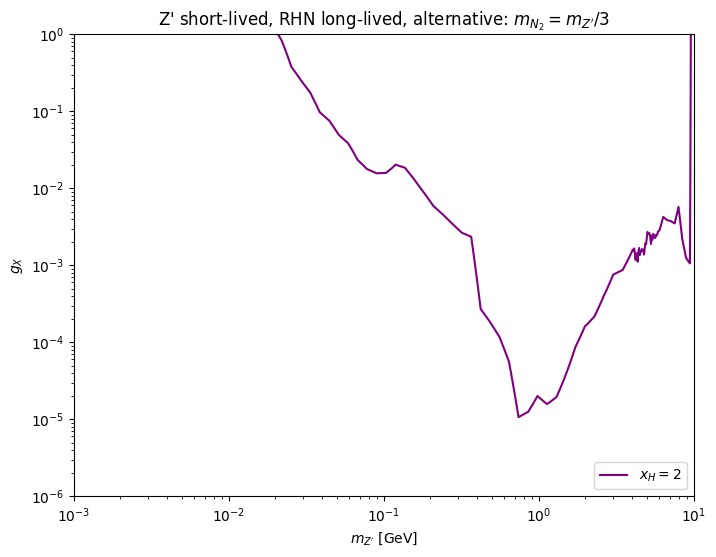

In [18]:
setups = [
         ["14TeV_alternative2n.npy",    r"$x_H = -2$"  , "purple", "solid", 0., 3],#*150/3000],
         ["14TeV_alternative12n.npy",    r"$x_H = -1,2$"  , "blue", "solid", 0., 3],#*150/3000],
         ["14TeV_alternative0.npy",    r"$x_H = 0$"  , "maroon", "solid", 0., 3],#*150/3000]]  
         ["14TeV_alternative2p.npy",    r"$x_H = 2$"  , "purple", "solid", 0., 3]#*150/3000]]
]

for setup in setups:
    fig, ax = plt.subplots()
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load(model.modelpath+"model/results_RHN3_mu/"+filename, allow_pickle=True, encoding='latin1')
    m, c = np.meshgrid(masses, couplings)
    n = np.log10(np.array(nsignals).T+1e-20)
    ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, clabel=label)
    ax.plot([0],[0],label=label, color=color)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$m_{Z'}$ [GeV]") 
    ax.set_ylabel(r"$g_X$")
    plt.rcParams["figure.figsize"]=(8,6)
    ax.set_xlim(1e-3, 10)
    ax.set_ylim(1e-6, 1)
    ax.legend(loc = "lower right")
    ax.set_title(r"Z' short-lived, RHN long-lived, alternative: $m_{N_2} = m_{Z'}/3$")
    plt.savefig(model.modelpath+"model/results_RHN3_mu/plots/"+filename+".png")